<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/OBB_with_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Oriented Bounding Boxes (OBB) with YOLOv8**

## **Context**

**What are Oriented Bounding Boxes (OBB)?**

**Oriented Bounding Boxes (OBB)** are an extension of traditional axis-aligned bounding boxes (AABB). While AABBs are always aligned with the coordinate axes (meaning they are always rectangular and parallel to the image borders), OBBs can be rotated at any angle.

**Key Characteristics**

*   **Rotation:** OBBs can enclose objects more tightly by rotating to match the object's orientation. This is particularly useful for objects that are not axis-aligned, such as vehicles in aerial imagery, ships, or long, narrow objects.
*   **Reduced Background Noise:** By conforming more closely to the object's shape, OBBs include less background information compared to AABBs, which can lead to more accurate object detection, classification, and segmentation in some scenarios.
*   **Representation:** An OBB is typically defined by its center point (x, y), width, height, and an angle of rotation.

**Why use OBBs?**

OBBs are especially beneficial in applications where object orientation is crucial or where objects are densely packed and irregularly oriented, such as:

*   **Aerial and Satellite Imagery:** Detecting ships, airplanes, or buildings from an overhead perspective.
*   **Text Detection:** Accurately bounding skewed or rotated text.
*   **Industrial Inspection:** Identifying defects or objects on conveyor belts that might be oriented arbitrarily.
*   **Autonomous Driving:** Better localization of vehicles and pedestrians that are not perfectly aligned with the camera's view.

**Advantages of OBB with YOLOv8**

*   **Enhanced Precision:** OBBs provide a more accurate localization of objects, especially those with significant aspect ratios or arbitrary orientations, leading to reduced false positives and improved detection performance.
*   **Reduced Ambiguity:** By tightly enclosing objects, OBBs minimize overlap between adjacent objects in dense scenes, making it easier to distinguish individual instances.
*   **Richer Information:** The inclusion of orientation angle provides valuable contextual information that can be critical for tasks like robotic manipulation, autonomous navigation, or object tracking.
*   **Improved Feature Extraction:** With less background noise within the bounding box, features extracted from OBB regions are often more discriminative, benefiting subsequent classification or re-identification tasks.
*   **Versatility:** YOLOv8's OBB capability extends its applicability to domains where traditional AABBs fall short, such as remote sensing, industrial inspection, and document analysis.

**Limitations of OBB with YOLOv8**

*   **Increased Complexity:** Predicting an additional angle parameter makes the model more complex than AABB models, potentially requiring more computational resources for training and inference.
*   **Annotation Effort:** Collecting and annotating datasets with OBBs is more labor-intensive and time-consuming than for AABBs, as it requires defining not just the extent but also the orientation of each object.
*   **Angle Sensitivity:** Small errors in angle prediction can lead to significant misalignment, especially for very long and thin objects.
*   **Boundary Cases:** For perfectly square or circular objects, the orientation might be ambiguous or less meaningful, potentially leading to inconsistent predictions.
*   **Performance Overhead:** While offering higher precision, the added complexity of OBB might introduce a slight performance overhead compared to simpler AABB models, especially on edge devices or in real-time applications with strict latency requirements.

In this notebook, we are using YOLOv8 with OBB capabilities, which means the model is trained to predict these rotated bounding boxes, providing a more precise localization of objects in the images.

**Initial setup**

In [30]:
# Installing additional library
#!pip install ultralytics #Remove the ('#') to install

In [3]:
# Importing libraries
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## **OBB detection with YOLOv8**

In [5]:
# Preparing YOLOv8 & downloading starter files

model = YOLO('yolov8x-obb.pt')

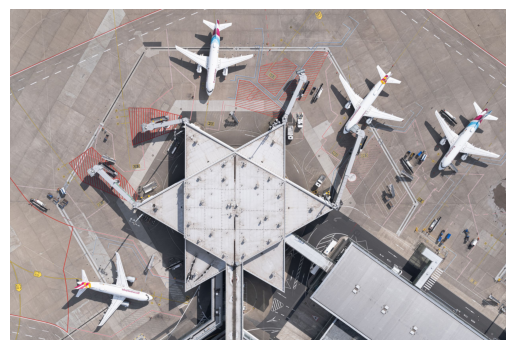

In [24]:
# Attaching the input image

# Image link
url_airport = 'https://media.cnn.com/api/v1/images/stellar/prod/210428142531-05b-tom-hegen-airports-aerial-photos-restricted.jpg?q=w_2500,h_1667,x_0,y_0,c_fill'


# Download and open the image
with urllib.request.urlopen(url_airport) as f:
    input_img_airport = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img_airport = np.array(input_img_airport)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img_airport, cmap='gray')
plt.show()


0: 704x1024 4 planes, 8777.5ms
Speed: 9.5ms preprocess, 8777.5ms inference, 2.1ms postprocess per image at shape (1, 3, 704, 1024)


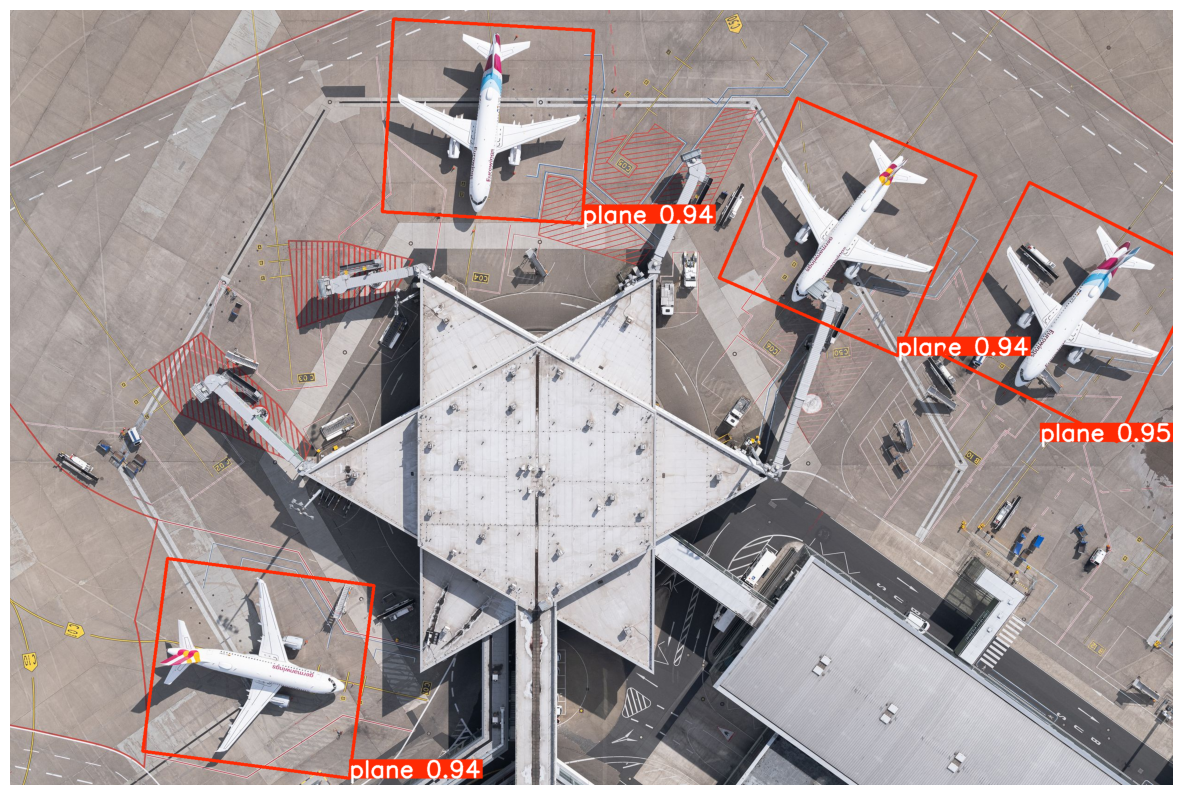

In [25]:
# Conduting detection with OBB (YOLOv8) on the second input image
prediction = model.predict(input_img_airport, agnostic_nms=True)
result = prediction[0]

# plot detection result on the second input image
img_detect_airport = result.plot(line_width=5, conf=0.5)

# Displaying the detected image
plt.figure(figsize=(15,15))
plt.axis('off')
plt.imshow(img_detect_airport)
plt.show()

We have detected 4 images of plane

Now, lets try the model performance on another image.

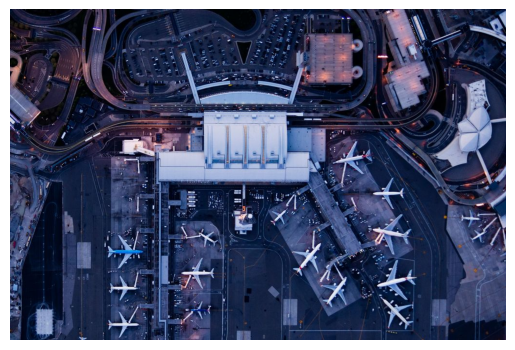

In [26]:
# Attaching the 2nd input image

# Image link
url_airport2 = 'https://media.architecturaldigest.com/photos/581261d979be6d840e3de9cc/master/w_1024%2Cc_limit/airports-01.jpg'

# Download and open the image
with urllib.request.urlopen(url_airport2) as f:
    input_img_airport2 = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img_airport2 = np.array(input_img_airport2)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img_airport2, cmap='gray')
plt.show()


0: 704x1024 17 planes, 8956.1ms
Speed: 6.7ms preprocess, 8956.1ms inference, 2.6ms postprocess per image at shape (1, 3, 704, 1024)


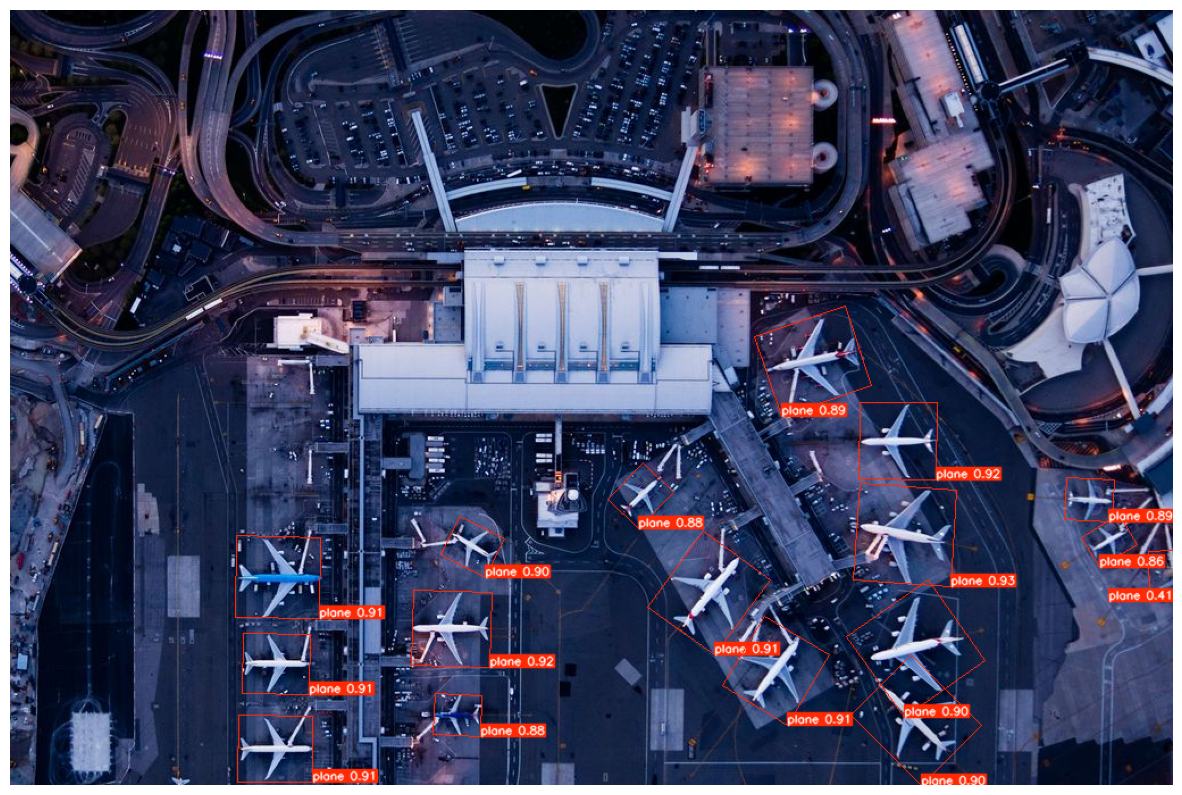

In [27]:
# Conduting detection with OBB (YOLOv8) on the second input image
prediction = model.predict(input_img_airport2, agnostic_nms=True)
result = prediction[0]

# plot detection result on the second input image
img_detect_airport2 = result.plot(line_width=1, conf=0.5)

# Displaying the detected image
plt.figure(figsize=(15,15))
plt.axis('off')
plt.imshow(img_detect_airport2)
plt.show()

We have detected 17 planes from the second aerial view image.

Now, let's try another aerial view object.

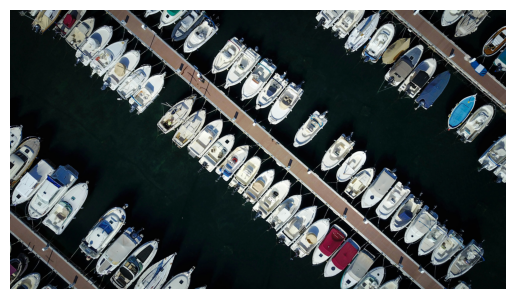

In [28]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/aerial-kapal.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()


0: 576x1024 76 ships, 6289.7ms
Speed: 10.1ms preprocess, 6289.7ms inference, 38.6ms postprocess per image at shape (1, 3, 576, 1024)


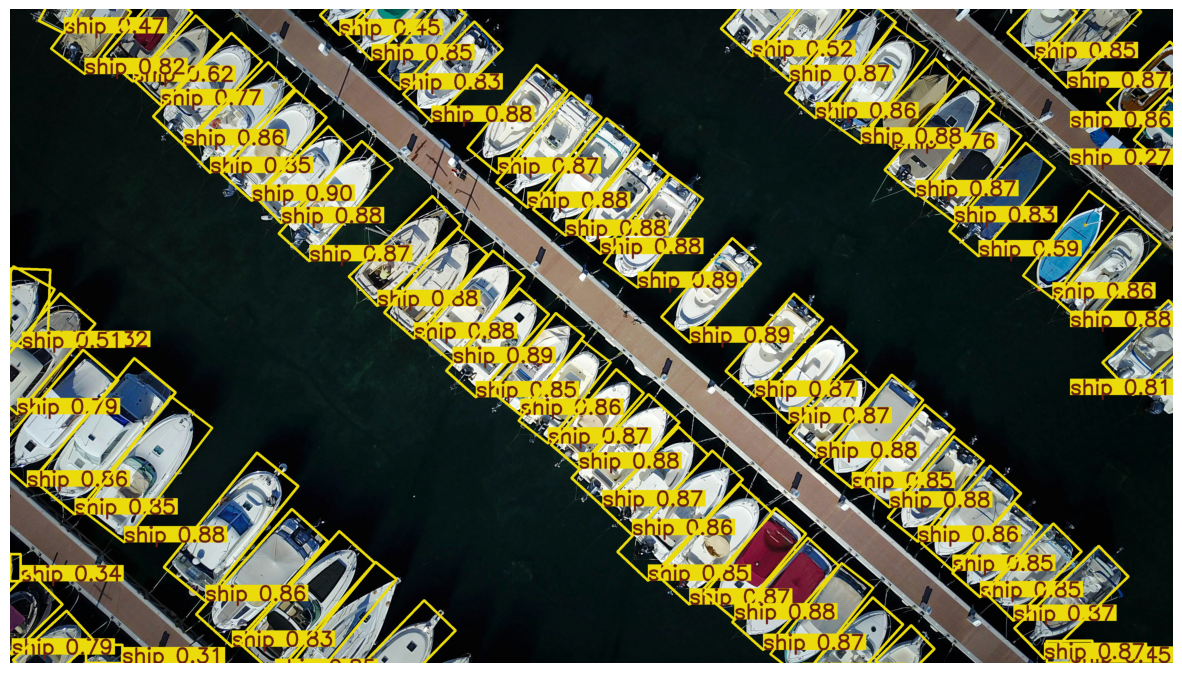

In [29]:
# Conduting detection with OBB (YOLOv8) in input image
prediction = model.predict(input_img, agnostic_nms=True)
result = prediction[0]

# plot detection result on the input image
img_detect = result.plot(line_width=7, conf=0.5)

# Displaying the detected image
plt.figure(figsize=(15,15))
plt.axis('off')
plt.imshow(img_detect)
plt.show()

We have detected about 76 ships from aerial view.

## **Conclusion**

This tutorial demonstrates the capability of YOLOv8 with Oriented Bounding Boxes (OBB) for object detection, particularly in aerial imagery. We have explored the concept of OBBs, their advantages, and limitations, especially in the context of YOLOv8.

Key takeaways include:
*   OBBs provide precise localization for arbitrarily oriented objects
*   YOLOv8's OBB model can effectively detect and outline objects like planes and ships in complex aerial views, offering richer information including object orientation.